## Bland-Altman analysis to investigate intra-scanner variability of SC

In [9]:
import h5py
import numpy as np
import pandas as pd
from simulate_sc import (
    simulate_sc_length_bias,
    simulate_sc_density_bias,
    simulate_sc_fns,
    simulate_sc_fps,
)
from ba_plot import ba_plot

atlas_path="/data/probconnatlas/wm.connatlas.scale1.h5"

### Simulate SC matrices with a set biases
We will use simulated SC matrices with an artifical set bias in the within-scanner variability to develop a Bland-Altman analysis capable of detecting such biases. 
Once the methodology is refined, we will apply it on the real HCPh data.

In [10]:
SC_matrices = simulate_sc_length_bias(atlas_path=atlas_path)
num_sessions = SC_matrices.shape[0]
atlas_dim = SC_matrices.shape[1]

Using the connectome atlas as reference SC matrix.
Simulated a series of 36 SC matrices of shape (95x95) with higher variability in long connections.


### Prepare the dataframe to input into the Bland-Altman analyses

We first prepare an SC matrices array by keeping only the lower triangle of each SC matrix and unravel it into a row vector.

In [11]:
# Extract the lower triangle of each SC matrix and unravel it into a row vector
SC_matrices_tril = np.array(
    [SC_matrices[i][np.tril_indices(atlas_dim, k=-1)] for i in range(num_sessions)]
)

print(SC_matrices_tril.shape)
# Test whether the shape is as expected
assert SC_matrices_tril.shape == (num_sessions, atlas_dim * (atlas_dim - 1) // 2)

(36, 4465)


We randomly assign half of the session to one group and the other half to another group. We will consider those two random groups as our two methods of measurements. Once the group assignement is made, we count the repetition index of each session within the group. Finally, we combine all these information in a dataframe.

In [12]:
def assign_repl(random_group):
    # DO WE NEED TO RANDOMIZE REPLICATION ASSIGNEMENT OR WE PRESERVE THE ORIGINAL SESSION ORDER (= what we do for now)?
    # Generate a vector that establishes the repetition index based on random group assignment
    count_group2 = np.cumsum(random_group == 2)
    indices1 = np.where(random_group == 1)
    count_group2[indices1] = 0

    count_group1 = np.cumsum(random_group == 1)
    indices2 = np.where(random_group == 2)
    count_group1[indices2] = 0
    repl = count_group1 + count_group2
    
    return repl

# Randomly assign half of the sessions to one group and half to another, we will consider those two random groups as our two methods of measurement
random_group = np.random.permutation([1] * int(num_sessions/2) + [2] * int(num_sessions/2)) # DO WE NEED THIS TO BE REPRODUCIBLE OR NOT?
# Establish the repetition index
repl = assign_repl(random_group)
print(f"Random group vector: {random_group}")
print(f"Replication vector: {repl}")
# Test if the function behaves as it should
assert np.array_equal(assign_repl(np.array([2, 2, 1, 2, 1, 2])), [1, 2, 1, 3, 2, 4]), f"{assign_repl([2, 2, 1, 2, 1, 2])} != [1, 2, 1, 3, 2, 4], establishement of repetition index is broken"

Random group vector: [1 2 1 1 2 2 2 2 2 2 2 1 2 1 2 2 2 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 1 2 1 2]
Replication vector: [ 1  1  2  3  2  3  4  5  6  7  8  4  9  5 10 11 12  6  7  8  9 10 11 12
 13 14 15 16 13 14 15 16 17 17 18 18]


In [13]:
# Create a DataFrame combining random_group, repl, and SC_matrices_tril
df_sc = pd.DataFrame(SC_matrices_tril, columns=[f"connection_{i}" for i in range(SC_matrices_tril.shape[1])])
df_sc.insert(0, "random_group", random_group)
df_sc.insert(1, "replication", repl)

print(df_sc)

    random_group  replication  connection_0  connection_1  connection_2  \
0              1            1    701.246284    391.891856     35.738770   
1              2            1    701.246151    391.892037     35.738255   
2              1            2    701.246099    391.891728     35.738525   
3              1            3    701.246735    391.892271     35.739983   
4              2            2    701.246691    391.892167     35.738295   
5              2            3    701.246641    391.892644     35.738770   
6              2            4    701.245045    391.892252     35.738504   
7              2            5    701.246449    391.892113     35.737932   
8              2            6    701.245038    391.892064     35.738364   
9              2            7    701.245857    391.892520     35.738913   
10             2            8    701.245275    391.892185     35.739439   
11             1            4    701.245211    391.892408     35.738689   
12             2         

In [14]:
import statsmodels.formula.api as smf

df = df_sc.melt(
        id_vars=["random_group", "replication"],
        var_name="connection_index",
        value_name="sc",
    )

# Replace NaN values in the 'sc' column with zero
df['sc'].fillna(0, inplace=True)

df.to_csv("sc_dataframe_for_R.csv", index=False)
print(df)

# md = smf.mixedlm("sc ~ random_group + connection_index", df, groups= df["connection_index"], re_formula='0 + random_group')
# mdf = md.fit()
# print(mdf.summary())

        random_group  replication connection_index          sc
0                  1            1     connection_0  701.246284
1                  2            1     connection_0  701.246151
2                  1            2     connection_0  701.246099
3                  1            3     connection_0  701.246735
4                  2            2     connection_0  701.246691
...              ...          ...              ...         ...
160735             2           16  connection_4464  168.591067
160736             1           17  connection_4464  168.590233
160737             2           17  connection_4464  168.590943
160738             1           18  connection_4464  168.590548
160739             2           18  connection_4464  168.591579

[160740 rows x 4 columns]


## Pre-registered analysis

We compute all pairwise subtractions of sessions (that is rows in SC_matrices) and plot the BA plot for the ten connections with the largest pairwise differences (normalized by the average difference in the pool).


#### Identify the connections corresponding to the 10 largest differences

In [15]:
import pandas as pd

# Convert NaN to zeros to correctly compute differences
SC_matrices_tril[np.isnan(SC_matrices_tril)] = 0

# Compute absolute value of pairwise subtractions for unique pairs (i, j) where i < j
sessions_subtractions = []
session_pairs = []
for i in range(num_sessions):
    for j in range(i + 1, num_sessions):
        subtraction = np.abs(SC_matrices_tril[i] - SC_matrices_tril[j])
        sessions_subtractions.append(subtraction)
        session_pairs.append((i, j))

sessions_subtractions = np.array(sessions_subtractions)
assert sessions_subtractions.shape == (
    num_sessions * (num_sessions - 1) // 2,
    atlas_dim * (atlas_dim - 1) // 2,
)

# Normalize the subtractions by the grand mean value of each connection
grand_mean = np.mean(sessions_subtractions, axis=0)
# Divide by connection grand mean only if it is not zero
non_zero_indices = np.where(grand_mean != 0)[0]
assert grand_mean.shape == (atlas_dim * (atlas_dim - 1) // 2,)
sessions_subtractions[:, non_zero_indices] = (
    sessions_subtractions[:, non_zero_indices] / grand_mean[non_zero_indices]
)
assert sessions_subtractions.shape == (
    num_sessions * (num_sessions - 1) // 2,
    atlas_dim * (atlas_dim - 1) // 2,
)

# Identify the 10 maximum element-wise subtractions in sessions_subtractions
max_indices = np.unravel_index(
    np.argsort(sessions_subtractions, axis=None)[-10:], sessions_subtractions.shape
)
max_values = sessions_subtractions[max_indices]
# Verify that we indeed extract the 10 maximum differences
assert np.min(max_values) > np.max(
    np.ma.masked_array(
        sessions_subtractions, mask=np.isin(sessions_subtractions, max_values)
    )
)

print(
    f"The 10 biggest differences in a structural connection value between two sessions are: {max_values}"
)
# Extract the session pairs corresponding to the 10 biggest differences
max_session_pairs = [session_pairs[idx] for idx in max_indices[0]]

print(
    f"The session pairs corresponding to the 10 biggest differences are: {max_session_pairs}"
)
print(
    f"The connection corresponding to the 10 biggest differences are {max_indices[1]}"
)  # TO DO: match connections indices to the brain regions

The 10 biggest differences in a structural connection value between two sessions are: [5.43791751 5.48527707 5.53175591 5.55133366 5.57853585 5.584353
 5.74290901 5.74723868 5.84069805 6.10223652]
The session pairs corresponding to the 10 biggest differences are: [(22, 34), (27, 33), (26, 33), (22, 30), (17, 20), (1, 20), (16, 34), (13, 15), (28, 34), (4, 10)]
The connection corresponding to the 10 biggest differences are [ 888 4403 2164 3676 2275 3810 2325 3173 2095 3578]


#### Plot the BA plot of the connections with the biggest differences

(630,)


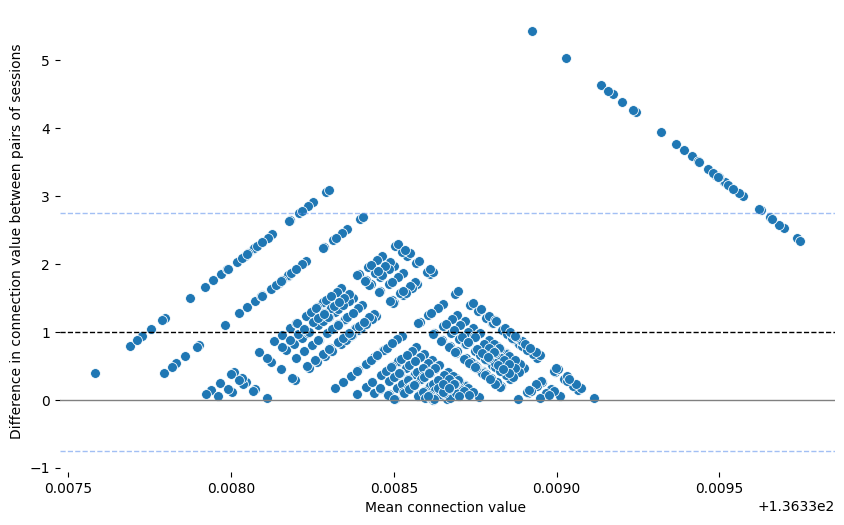

(630,)


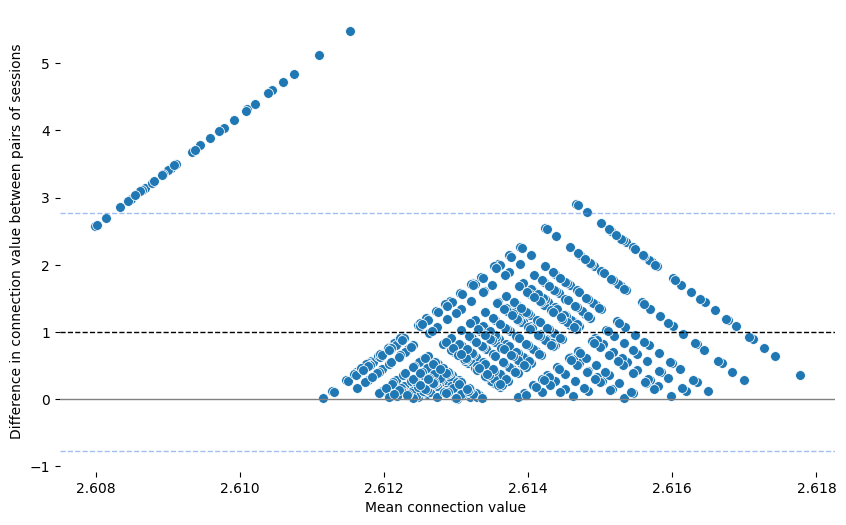

(630,)


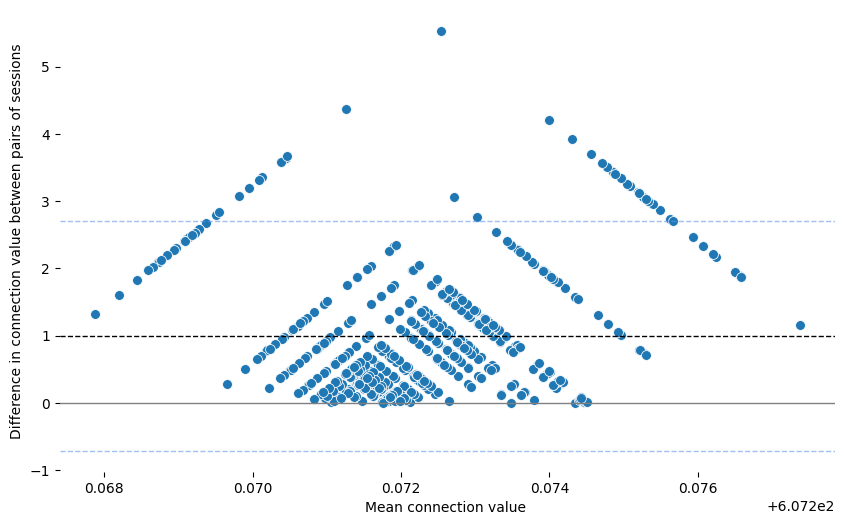

(630,)


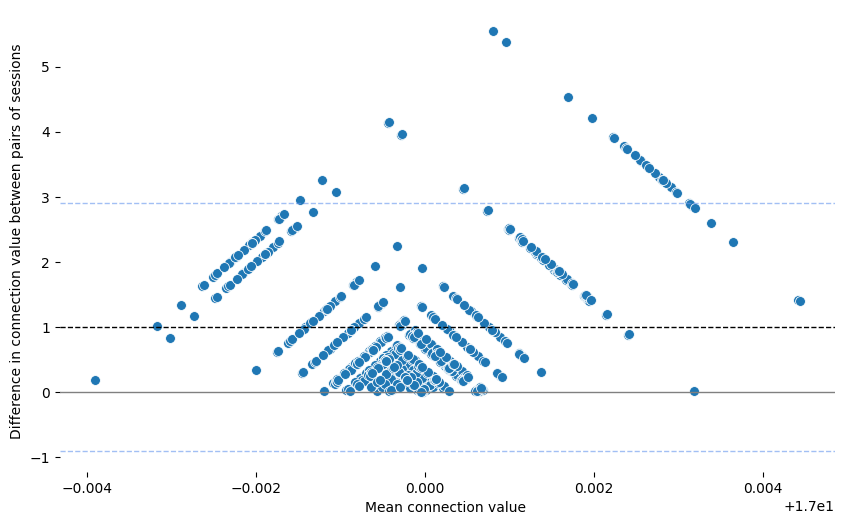

(630,)


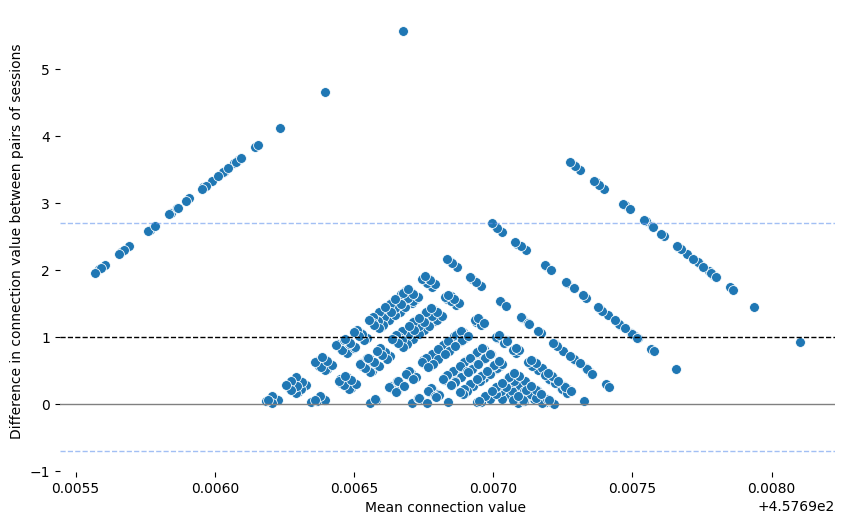

(630,)


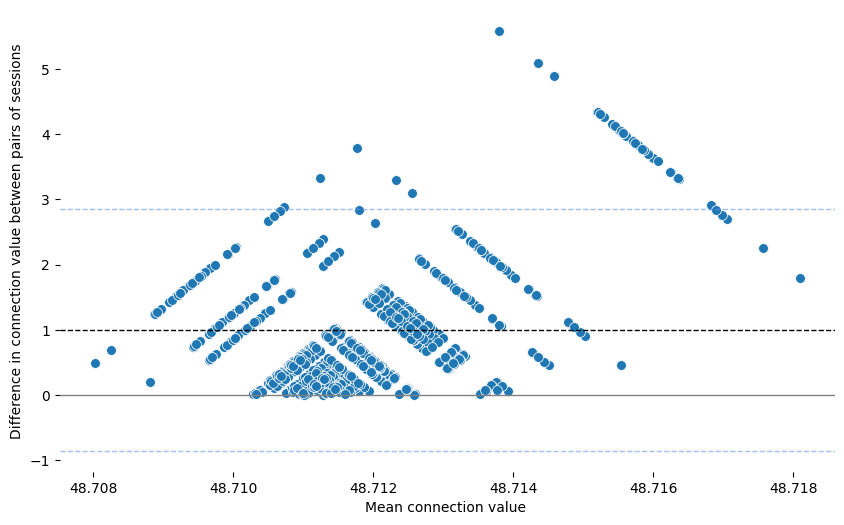

(630,)


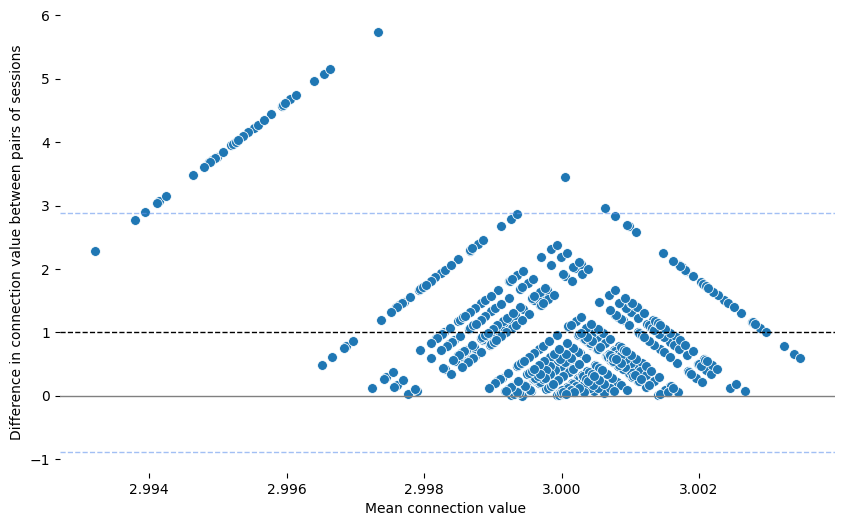

(630,)


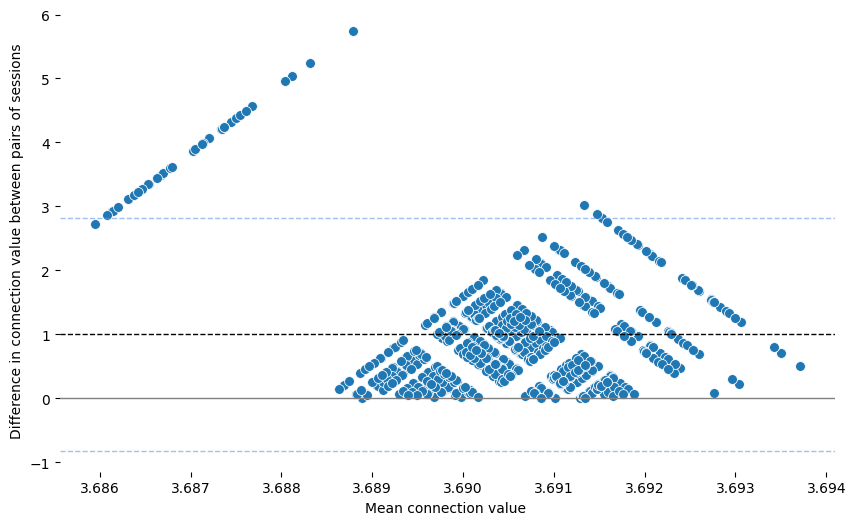

(630,)


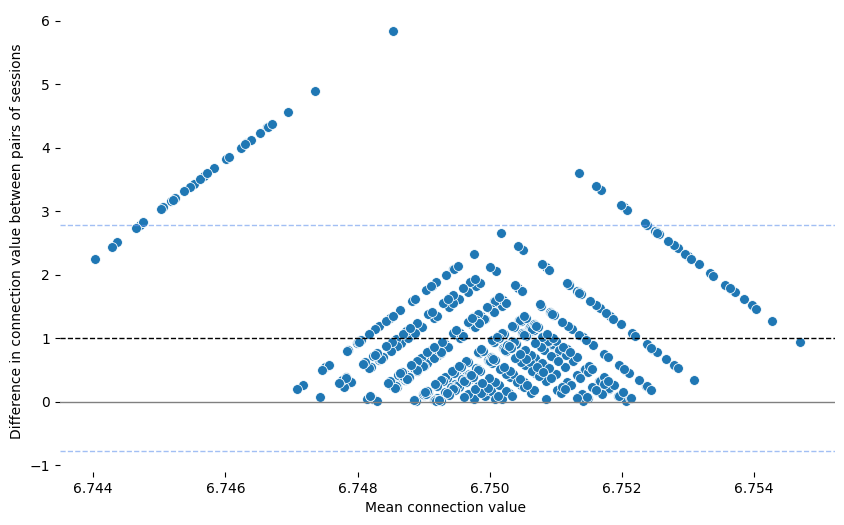

(630,)


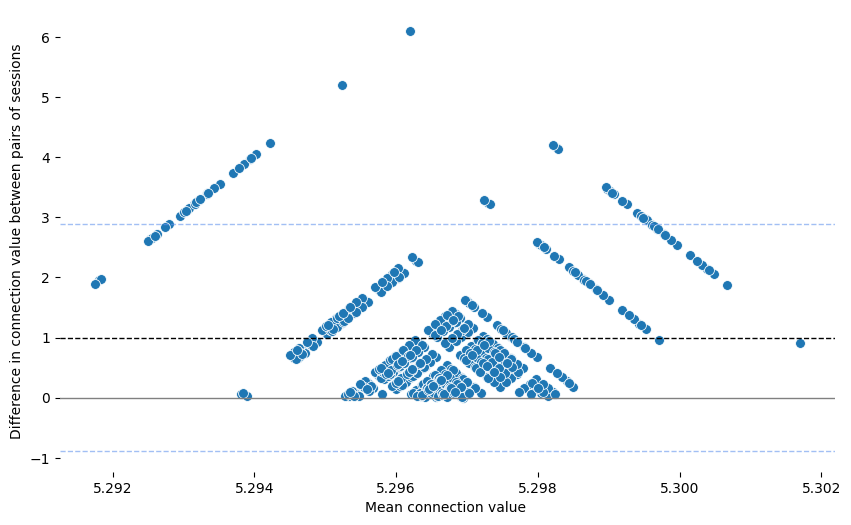

In [16]:
for conn in max_indices[1]:
    # Extract the vector of differences and means
    conn_diff = sessions_subtractions[:, conn]
    SC_value = SC_matrices_tril[:, conn]
    conn_mean = np.array([
        np.mean([SC_matrices_tril[i, conn], SC_matrices_tril[j, conn]])
        for i in range(num_sessions) 
        for j in range(i + 1, num_sessions)
    ])
    print(conn_diff.shape)
    assert conn_mean.shape == (num_sessions * (num_sessions - 1) // 2,)
    assert conn_diff.shape == conn_mean.shape, f"The mean vector has a shape of {conn_mean.shape} while the difference vector has a shape of {conn_diff.shape}."

    # Plot the corresponding BA plot
    ba_plot(
        diff= conn_diff,
        mean= conn_mean,
    )

## BA plot with all connections, all pair-wise session comparisons

In [17]:
with h5py.File(atlas_path, "r") as f:
        length_matrix = np.array(f["matrices"]["length"])

length_tril = length_matrix[np.tril_indices(atlas_dim, k=-1)]


print(length_tril.shape)


(4465,)


In [18]:
# Compute all pairwise mean for unique pairs (i, j) where i < j
sessions_means = []
for i in range(num_sessions):
    for j in range(i + 1, num_sessions):
        means = np.mean(np.vstack((SC_matrices_tril[i], SC_matrices_tril[j])), axis=0)
        sessions_means.append(means)

sessions_means = np.array(sessions_means)
sessions_means.shape

(630, 4465)

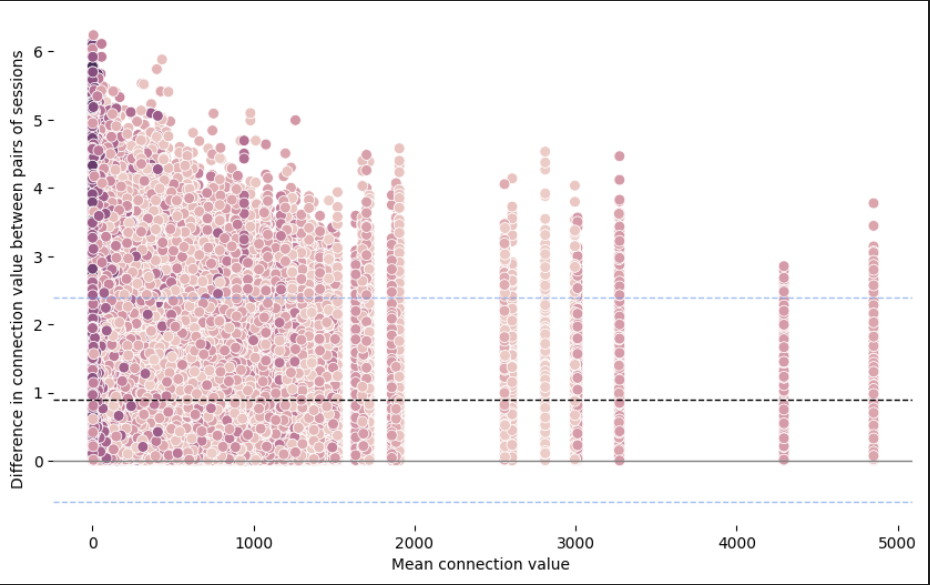

In [19]:
from IPython.display import Image, display

# # Compute all pairwise mean for unique pairs (i, j) where i < j
# sessions_means = []
# for i in range(num_sessions):
#     for j in range(i + 1, num_sessions):
#         means = np.mean(np.vstack((SC_matrices_tril[i], SC_matrices_tril[j])), axis=0)
#         sessions_means.append(means)

# sessions_means = np.array(sessions_means)
# sessions_means.shape

# length_hue = np.tile(length_tril, num_sessions * (num_sessions - 1) // 2)
# np.testing.assert_array_equal(length_hue[:len(length_tril)], length_tril)

# ba_plot(
#     diff = sessions_subtractions.flatten(),
#     mean = sessions_means.flatten(), 
#     hue = length_hue,
# )
# Display the photo
image_path = "/home/cprovins/Documents/HCPh_analysis/BAplot_allconnections_lengthhue.png"
display(Image(filename=image_path))
